In [1]:
import os
os.environ["IPFS_GATEWAY"] = "https://ipfs.orcestra-campaign.org"

In [2]:
import xarray as xr

In [3]:
import xarray as xr

ds = xr.open_dataset("ipfs://bafybeigmd3dovwm45ylfqxnn2jphsrdjl2jt3dfytv7grkyhleaq42jthe", engine="zarr")


/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'datamet' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
 

In [4]:
ds

<xarray.Dataset> Size: 48GB
Dimensions:             (time: 855344, height: 503)
Coordinates:
  * height              (height) float64 4kB 0.0 30.0 ... 1.503e+04 1.506e+04
  * time                (time) datetime64[ns] 7MB 2024-08-09T09:52:05.097473 ...
Data variables: (12/58)
    DPS                 (time, height) float32 2GB ...
    DetuneFine          (time) float32 3MB ...
    HSDco               (time, height) float32 2GB ...
    HSDcx               (time, height) float32 2GB ...
    ISDRco              (time, height) float32 2GB ...
    ISDRcx              (time, height) float32 2GB ...
    ...                  ...
    plane_pitch         (time) float64 7MB ...
    plane_roll          (time) float64 7MB ...
    prf                 (time) float64 7MB ...
    rg0                 (time) float64 7MB ...
    tpow                (time) float32 3MB ...
    zrg                 (time) float64 7MB ...
Attributes: (12/16)
    convention:     CF-1.0
    creator_email:  jakob.deutloff@uni-hamburg.de, lukas.kluft@mpimet.mpg.de,...
    creator_name:   Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:    trajectoryProfile
    history:        The processing software is available at https://github.co...
    keywords:       Cloud Radar, HALO, ORCESTRA, PERCUSION, Tropical Atlantic
    ...             ...
    reference:      Ka Band Cloud Radar MIRA, METEK GmbH www.metek.de
    references:     10.5194/amt-12-1815-2019, 10.5194/essd-13-5545-2021
    summary:        This dataset contains measurements from the MIRA cloud ra...
    system:         HAXC
    title:          MIRA Cloud Radar Moments from the HALO Microwave Package ...
    version:        1.0

In [5]:
import matplotlib.pyplot as plt

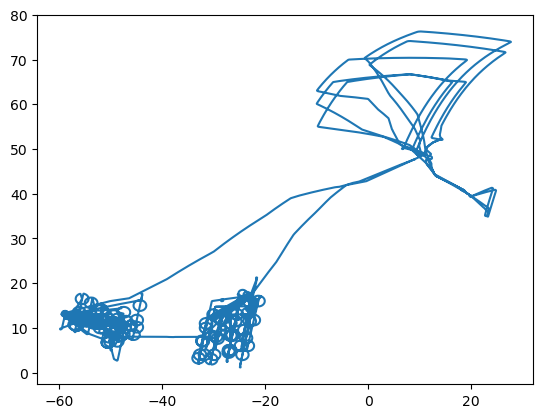

In [6]:
plt.plot(ds.lon, ds.lat)

In [7]:
ds = ds.sel(time=slice("2024-08-22-00:00:00", "2024-08-23-00:00:00"))

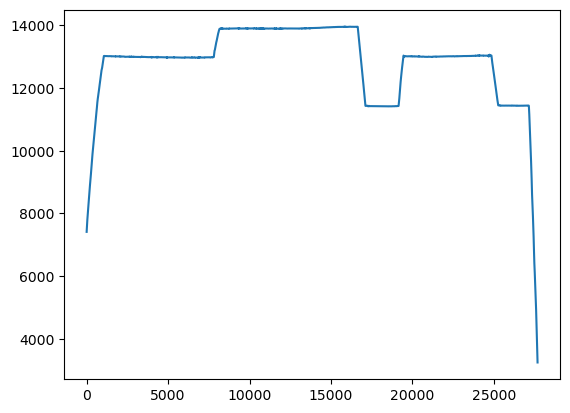

In [8]:
plt.plot(ds.plane_altitude)

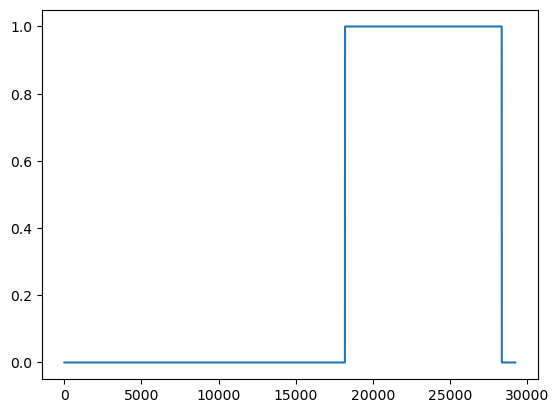

In [9]:
plt.plot(ds.plane_altitude>14100)

In [16]:
import numpy as np

In [17]:
ds.lon.size

27678

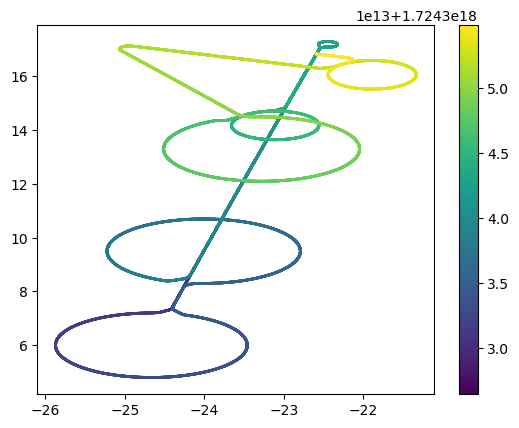

In [9]:
plt.scatter(ds.lon, ds.lat, c=ds.time, s=1)
plt.colorbar()

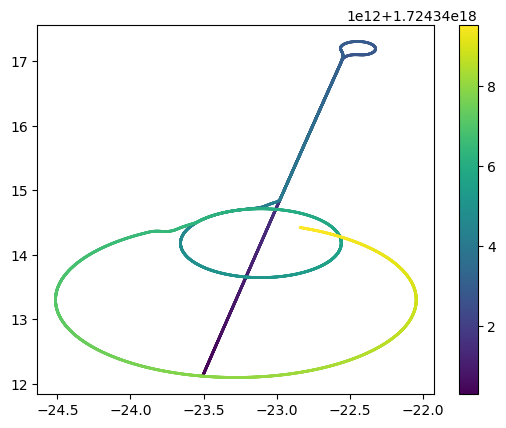

In [29]:
plt.scatter(ds.lon[13500:22500], ds.lat[13500:22500], c=ds.time[13500:22500], s=1)
plt.colorbar()

In [30]:
ds_halo = ds.isel(time=slice(13500, 22500))

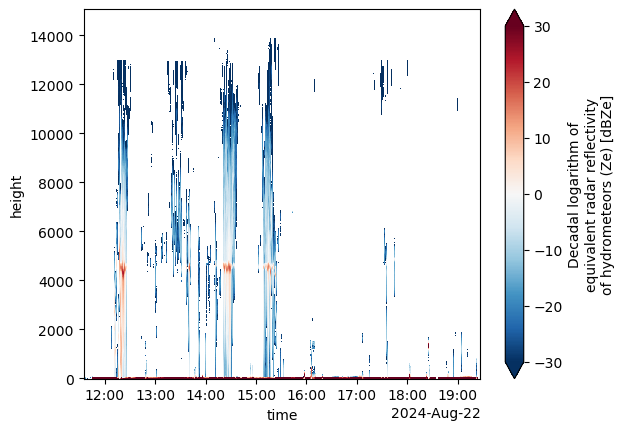

In [45]:
ds.dBZe.T.plot(cmap="RdBu_r", vmin=-30, vmax=30)

In [42]:
ds.dBZe

<xarray.DataArray 'dBZe' (time: 27678, height: 503)> Size: 56MB
[13922034 values with dtype=float32]
Coordinates:
  * height   (height) float64 4kB 0.0 30.0 60.0 ... 1.5e+04 1.503e+04 1.506e+04
  * time     (time) datetime64[ns] 221kB 2024-08-22T11:34:42.699711 ... 2024-...
Attributes:
    long_name:  Decadal logarithm of equivalent radar reflectivity of hydrome...
    units:      dBZe

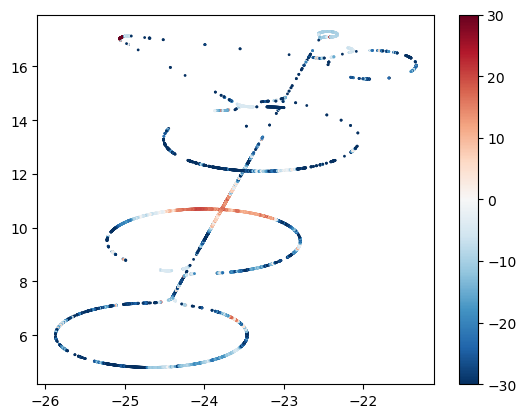

In [44]:
plt.scatter(ds.lon, ds.lat, c=ds.dBZe[:,10:].max("height"), s=1, cmap="RdBu_r", vmin=-30, vmax=30)
plt.colorbar()

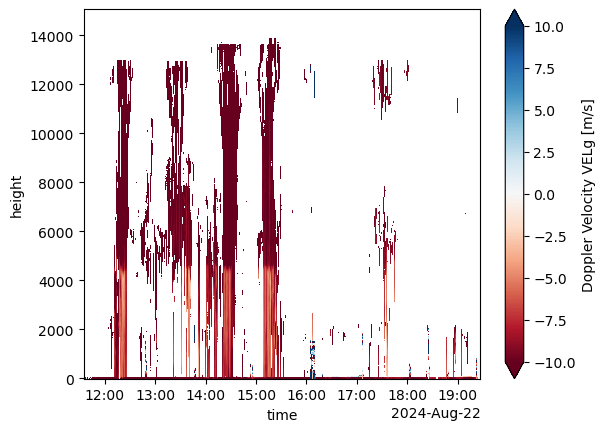

In [41]:
ds.VELg.T.plot(vmax=10, vmin=-10, cmap="RdBu")

In [33]:
ds_hamp_l2 = xr.open_dataset("ipfs://bafybeifxtmq5mpn7vwiiwl4vlpoil7rgm2tnhmkeyqsyudleqegxzvwl3a", engine="zarr")\
    .sel(time=slice("2024-08-22-00:00:00", "2024-08-23-00:00:00"))\
    .sel(altitude=slice(1.5e4,0))\
    .isel(time=slice(13500,22500))

In [34]:
ds_halo = ds_halo.sel(height=slice(0,1.5e4))

In [35]:
ds_halo

<xarray.Dataset> Size: 507MB
Dimensions:             (time: 9000, height: 501)
Coordinates:
  * height              (height) float64 4kB 0.0 30.0 60.0 ... 1.497e+04 1.5e+04
  * time                (time) datetime64[ns] 72kB 2024-08-22T15:25:08.550255...
Data variables: (12/58)
    DPS                 (time, height) float32 18MB ...
    DetuneFine          (time) float32 36kB ...
    HSDco               (time, height) float32 18MB ...
    HSDcx               (time, height) float32 18MB ...
    ISDRco              (time, height) float32 18MB ...
    ISDRcx              (time, height) float32 18MB ...
    ...                  ...
    plane_pitch         (time) float64 72kB ...
    plane_roll          (time) float64 72kB ...
    prf                 (time) float64 72kB ...
    rg0                 (time) float64 72kB ...
    tpow                (time) float32 36kB ...
    zrg                 (time) float64 72kB ...
Attributes: (12/16)
    convention:     CF-1.0
    creator_email:  jakob.deutloff@uni-hamburg.de, lukas.kluft@mpimet.mpg.de,...
    creator_name:   Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:    trajectoryProfile
    history:        The processing software is available at https://github.co...
    keywords:       Cloud Radar, HALO, ORCESTRA, PERCUSION, Tropical Atlantic
    ...             ...
    reference:      Ka Band Cloud Radar MIRA, METEK GmbH www.metek.de
    references:     10.5194/amt-12-1815-2019, 10.5194/essd-13-5545-2021
    summary:        This dataset contains measurements from the MIRA cloud ra...
    system:         HAXC
    title:          MIRA Cloud Radar Moments from the HALO Microwave Package ...
    version:        1.0

In [36]:
ds_hamp_l2.radar_doppler_velocity_corrected

<xarray.DataArray 'radar_doppler_velocity_corrected' (time: 9000, altitude: 501)> Size: 18MB
[4509000 values with dtype=float32]
Coordinates:
  * altitude  (altitude) float32 2kB 1.5e+04 1.497e+04 1.494e+04 ... 30.0 0.0
  * time      (time) datetime64[ns] 72kB 2024-08-22T15:25:08.550255104 ... 20...
Attributes:
    units:          m s-1
    positive:       up
    standard_name:  radial_velocity_of_scatterers_toward_instrument
    long_name:      Doppler velocity (corrected)
    description:    Vertical doppler velocity (upward is positive, motion cor...

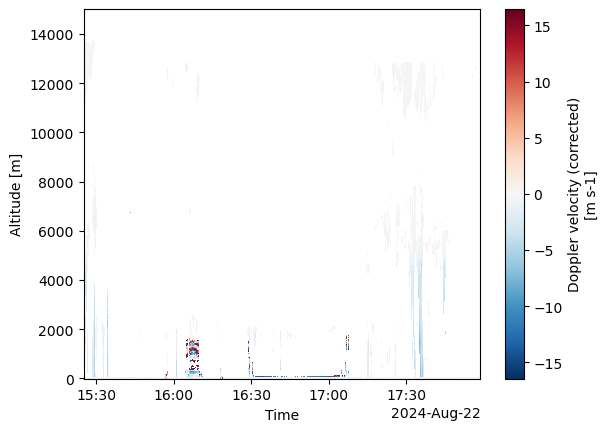

In [37]:
ds_hamp_l2.radar_doppler_velocity_corrected.T.plot()

In [38]:
ds_halo["radar_doppler_velocity_corrected"] = (
    ("time", "height"),
    ds_hamp_l2.radar_doppler_velocity_corrected.values[:,::-1]
)

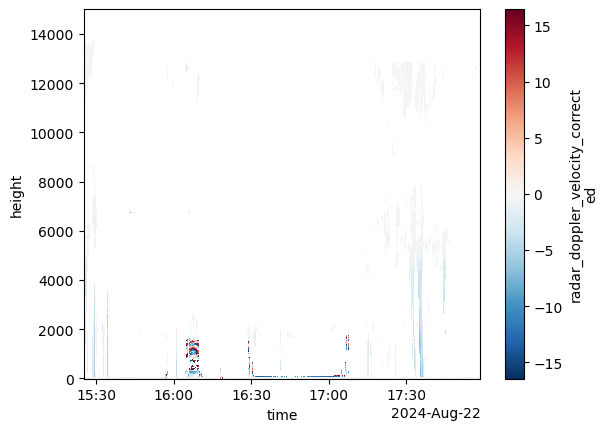

In [39]:
ds_halo.radar_doppler_velocity_corrected.T.plot()

In [24]:
from pystac_client import Client

catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']


In [25]:
ec_orbit="01271E"
ec_product="CPR_FMR_2A"

search = catalog.search(
    collections=EC_COLLECTION, 
    datetime="2024-08-18",
    bbox=(-72, -12, 0, 32), 
    filter=f"(productType = '{ec_product}') and orbitNumber = {ec_orbit[:-1]} and frame = '{ec_orbit[-1]}'", 
    method = 'GET', # This is necessary 
)

items = list(search.items())

In [26]:
items

[<Item id=ECA_EXBA_CPR_FMR_2A_20240818T155957Z_20250722T064339Z_01271E>]

In [27]:
from contextlib import contextmanager
import requests
import pathlib
import fsspec

CREDENTIALS_FILE = (pathlib.Path.home() / "credentials.txt" ).resolve()   # Insert the .txt path
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

def load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds


# --- ESA MAAP API ---

def get_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = load_credentials()

    OFFLINE_TOKEN = creds.get("OFFLINE_TOKEN")
    CLIENT_ID = creds.get("CLIENT_ID")
    CLIENT_SECRET = creds.get("CLIENT_SECRET")
    # print(CLIENT_SECRET)

    if not all([OFFLINE_TOKEN, CLIENT_ID, CLIENT_SECRET]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

token = get_token()
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {token}"}, 
    **io_params["fsspec_params"], 
)

@contextmanager
def read_ec_file(filename):
    try:
        f = fs.open(filename)
        ds = xr.open_dataset(
            f, 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        )
        yield ds
    finally:
        f.close()
        ds.close()

def select_vars(ds, data_vars):
    return ds.set_coords(["time", "latitude", "longitude", "height"])[data_vars]


In [28]:
product_vars = [
    "quality_status", 
    "reflectivity_corrected", 
    "multiple_scattering_status", 
]

In [29]:
import stratify
def regrid_dataset(ds, new_coord_values):
    new_ds = xr.Dataset(coords=ds.coords)
    dim = "CPR_height"
    coord = "height"
    new_ds[coord] = (dim,), new_coord_values
    for var in ds.data_vars:
        if dim in ds[var].dims:
            new_ds[var] = xr.DataArray(
                stratify.interpolate(
                    new_ds[coord].values,
                    ds[coord].fillna(-np.inf).values,
                    ds[var].values,
                    axis=ds[var].dims.index(dim),
                ), 
                dims=ds[var].dims, 
                name=var,
                attrs=ds[var].attrs,
            )
    return new_ds

In [30]:
with read_ec_file(items[0].assets.get('enclosure_h5').href) as ds:
    ds = select_vars(ds, product_vars)
    ds = ds.isel(
        along_track=np.logical_and.reduce([
            ds.latitude>=-12,
            ds.latitude<=32,
            ds.longitude>=-72,
            ds.longitude<=0
        ])
    )
    # print(ds.along_track.size)
    if ds.along_track.size > 0:
        ds.load()
        ds = (
            regrid_dataset(ds, np.arange(50, 2e4, 100)[::-1]).swap_dims(CPR_height="height")
        )

In [31]:
ds

<xarray.Dataset> Size: 12MB
Dimensions:                     (along_track: 3743, height: 200)
Coordinates:
    time                        (along_track) datetime64[ns] 30kB 2024-08-18T...
    latitude                    (along_track) float64 30kB 22.62 ... -11.99
    longitude                   (along_track) float64 30kB -26.61 ... -33.23
  * height                      (height) float64 2kB 1.995e+04 ... 50.0
Dimensions without coordinates: along_track
Data variables:
    quality_status              (along_track, height) float32 3MB 1.0 ... 1.0
    reflectivity_corrected      (along_track, height) float32 3MB nan ... nan
    multiple_scattering_status  (along_track, height) float64 6MB 0.0 ... 0.0

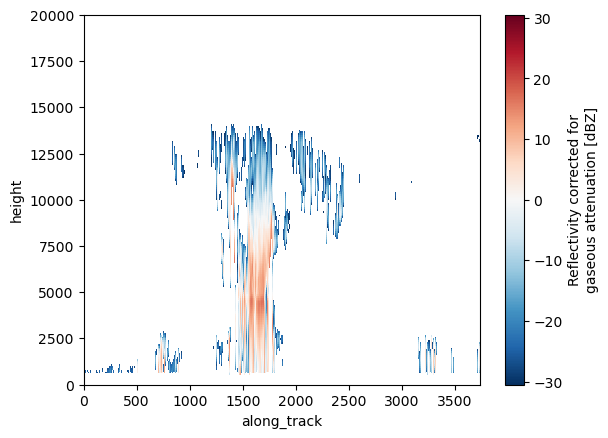

In [32]:
ds.reflectivity_corrected.where(ds.quality_status==0).T.plot()

In [33]:
fmr_ds = ds

In [34]:
ec_orbit="01271E"
ec_product="CPR_CD__2A"

search = catalog.search(
    collections=EC_COLLECTION, 
    datetime="2024-08-18",
    bbox=(-72, -12, 0, 32), 
    filter=f"(productType = '{ec_product}') and orbitNumber = {ec_orbit[:-1]} and frame = '{ec_orbit[-1]}'", 
    method = 'GET', # This is necessary 
)

items = list(search.items())

In [35]:
product_vars = [
    "doppler_velocity_best_estimate", 
    "sedimentation_velocity_best_estimate", 
    "spectrum_width_integrated", 
]

In [36]:
with read_ec_file(items[0].assets.get('enclosure_h5').href) as ds:
    ds = select_vars(ds, product_vars)
    ds = ds.isel(
        along_track=np.logical_and.reduce([
            ds.latitude>=-12,
            ds.latitude<=32,
            ds.longitude>=-72,
            ds.longitude<=0
        ])
    )
    # print(ds.along_track.size)
    if ds.along_track.size > 0:
        ds.load()
        ds = (
            regrid_dataset(ds, np.arange(50, 2e4, 100)[::-1]).swap_dims(CPR_height="height")
        )

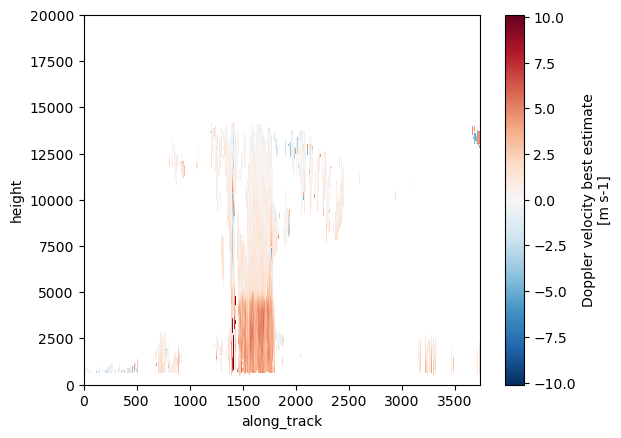

In [37]:
ds.doppler_velocity_best_estimate.T.plot()

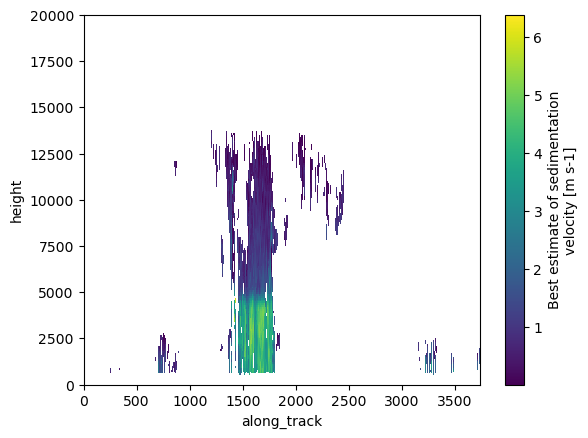

In [38]:
ds.sedimentation_velocity_best_estimate.T.plot()

In [39]:
# Create a balltree object to efficiently find nearest neighbours
import numpy as np
from sklearn.neighbors import BallTree
cpr_ll_tree = BallTree(
    np.radians(np.stack(
        [
            fmr_ds.latitude.values, 
            fmr_ds.longitude.values,
        ], axis=1
    )), 
    metric="haversine", 
)

In [40]:
distances, neighbours = cpr_ll_tree.query(
    np.radians(np.stack([ds_halo.lat.values, ds_halo.lon.values], axis=1))
)

In [41]:
neighbours

array([[2197],
       [2197],
       [2196],
       ...,
       [1386],
       [1386],
       [1386]])

In [42]:
ds_halo["along_track"] = ("time",), neighbours.ravel()

In [43]:
ds_halo_regridded = ds_halo.groupby("along_track").mean()

In [44]:
halo_regrid_time = ds_halo.time.groupby(ds_halo.along_track).mean()

In [45]:
np.abs(fmr_ds.time.sel(along_track=halo_regrid_time.along_track) - halo_regrid_time).idxmin()

<xarray.DataArray 'along_track' ()> Size: 8B
array(1714)

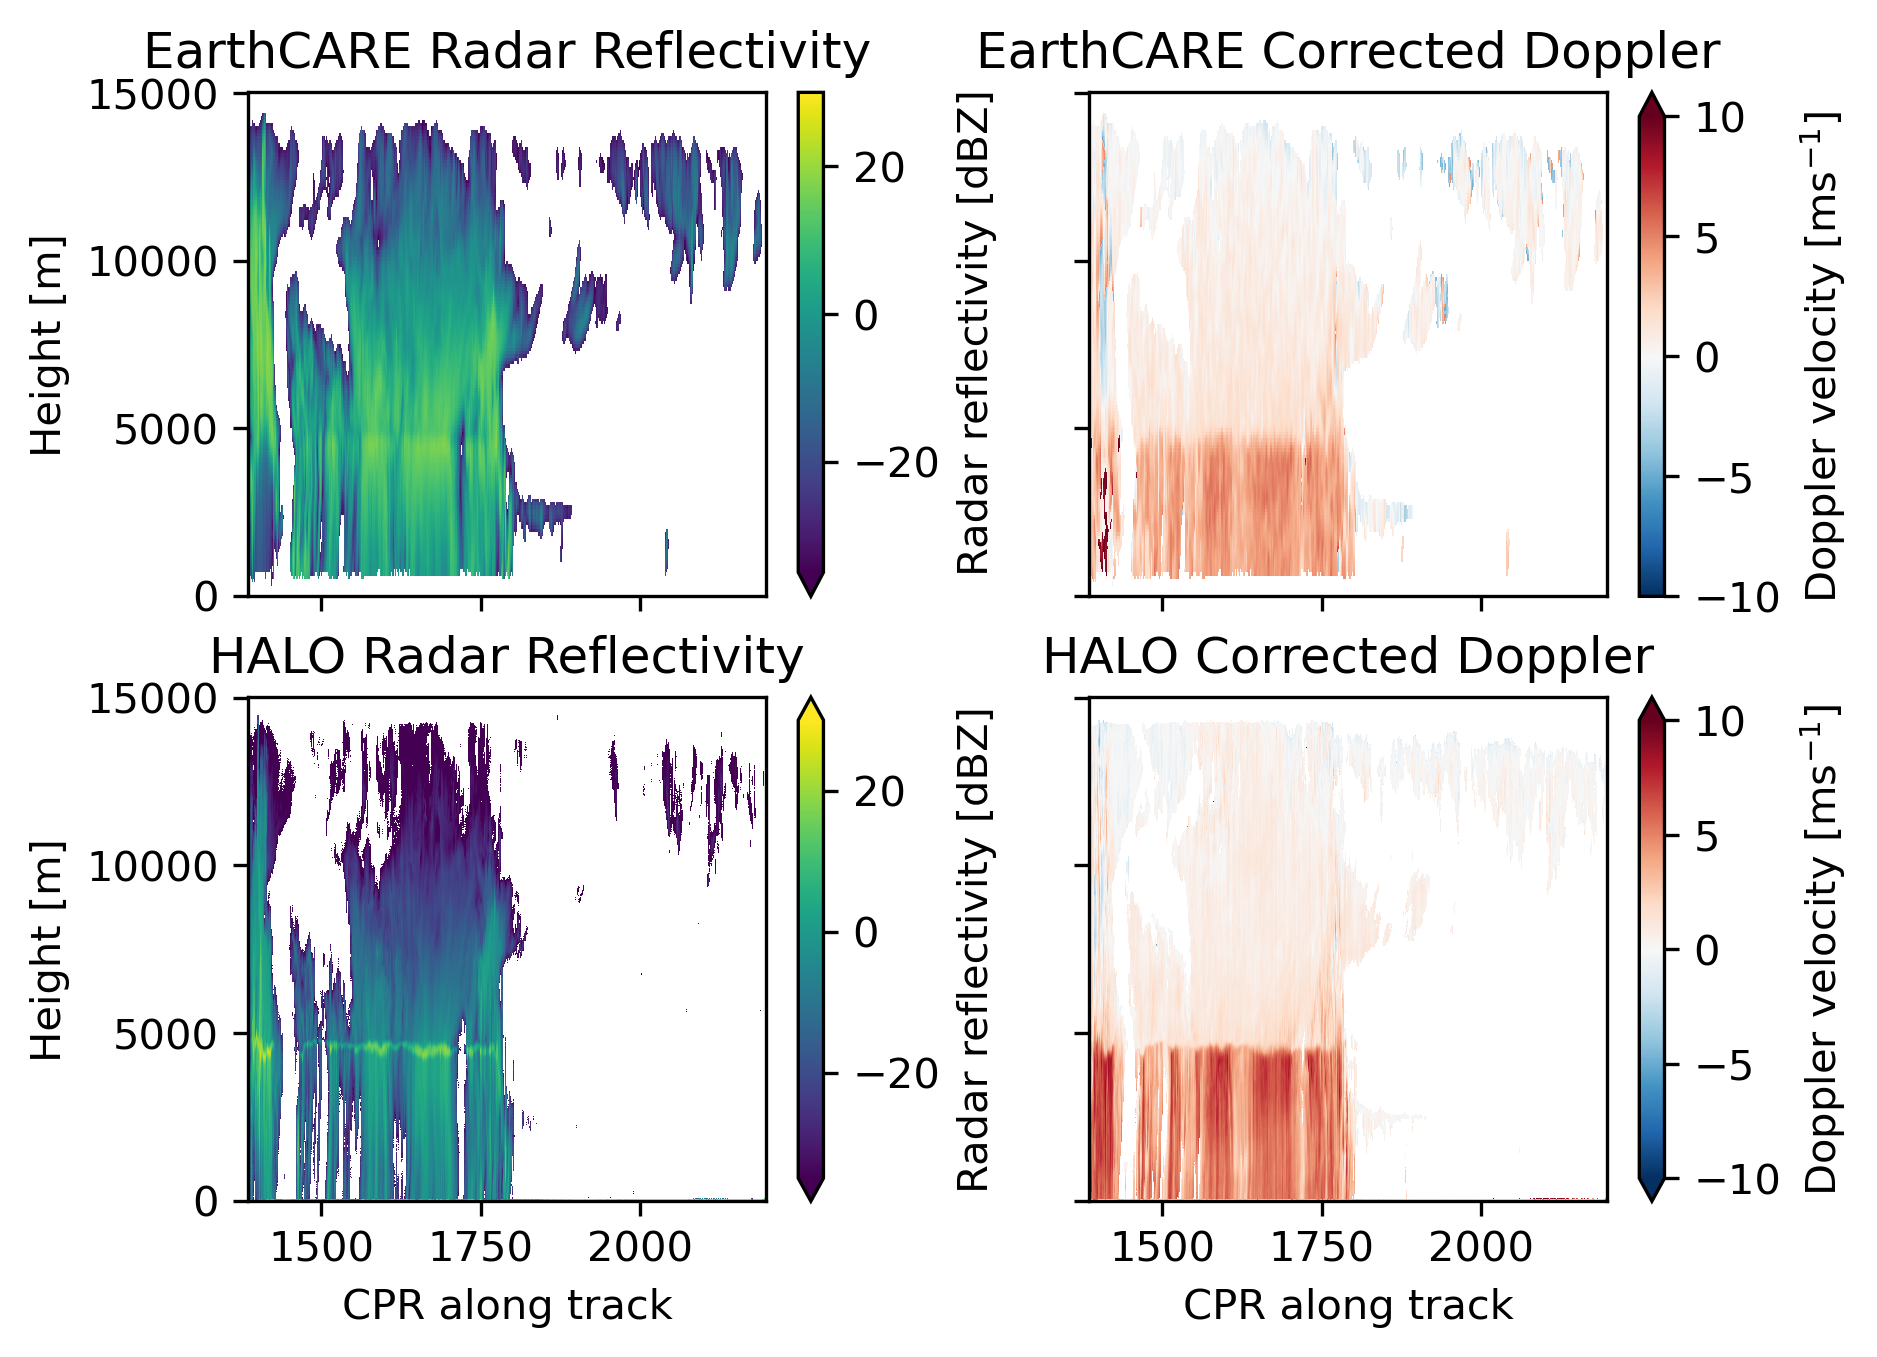

In [46]:
fig, axes = plt.subplots(2,2, dpi=300, sharex=True, sharey=True)

fmr_ds.reflectivity_corrected.T.plot(
    ax=axes[0,0], cmap="viridis", vmin=-35, vmax=30,
    cbar_kwargs=dict(label="Radar reflectivity [dBZ]")
)

ds_halo_regridded.dBZe.T.plot(
    ax=axes[1,0], cmap="viridis", vmin=-35, vmax=30,
    cbar_kwargs=dict(label="Radar reflectivity [dBZ]")
)

ds.doppler_velocity_best_estimate.T.plot(
    ax=axes[0,1], cmap="RdBu_r", vmin=-10, vmax=10,
    cbar_kwargs=dict(label="Doppler velocity [$\mathrm{ms^{-1}}$]")
)

(-ds_halo_regridded.radar_doppler_velocity_corrected).T.plot(
    ax=axes[1,1], cmap="RdBu_r", vmin=-10, vmax=10,
    cbar_kwargs=dict(label="Doppler velocity [$\mathrm{ms^{-1}}$]")
)

axes[0,0].set_ylabel("Height [m]")
axes[0,0].set_xlabel("")
axes[0,0].set_title("EarthCARE Radar Reflectivity")

axes[0,1].set_ylabel("")
axes[0,1].set_xlabel("")
axes[0,1].set_title("EarthCARE Corrected Doppler")

axes[1,0].set_ylabel("Height [m]")
axes[1,0].set_xlabel("CPR along track")
axes[1,0].set_title("HALO Radar Reflectivity")

axes[1,1].set_ylabel("")
axes[1,1].set_xlabel("CPR along track")
axes[1,1].set_title("HALO Corrected Doppler")

# for ax in axes.ravel():
#     ax.axvline(1714, c="C1", ls="--", alpha=0.5)

plt.subplots_adjust(wspace=0.3)

In [47]:
l1g_path = pathlib.Path("/work/scratch-nopw2/wkjones/EUM_L1g/")

In [49]:
bt_l1g = xr.open_dataset(
    sorted(list((l1g_path/"18").glob("*__temp_11_00um__*.nc")))[28]
)

In [53]:
bt = bt_l1g.temp_11_00um[0,0]

In [54]:
bt

<xarray.DataArray 'temp_11_00um' (latitude: 3600, longitude: 7200)> Size: 207MB
[25920000 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 29kB 89.98 89.93 89.88 ... -89.93 -89.98
  * longitude  (longitude) float64 58kB -180.0 -179.9 -179.9 ... 179.9 180.0
    time       datetime64[ns] 8B 2024-08-18T14:00:00
Attributes:
    units:                  K
    nickname:               IR Longwave Window Band
    central_wavelength_um:  11.0
    standard_name:          brightness_temperature

In [57]:
(
    ds_halo_regridded.lat.min().item(), 
    ds_halo_regridded.lat.max().item(), 
    ds_halo_regridded.lon.min().item(), 
    ds_halo_regridded.lon.max().item(), 
)

(2.3028055, 9.808219093333333, -30.5351698, -29.13691289333333)

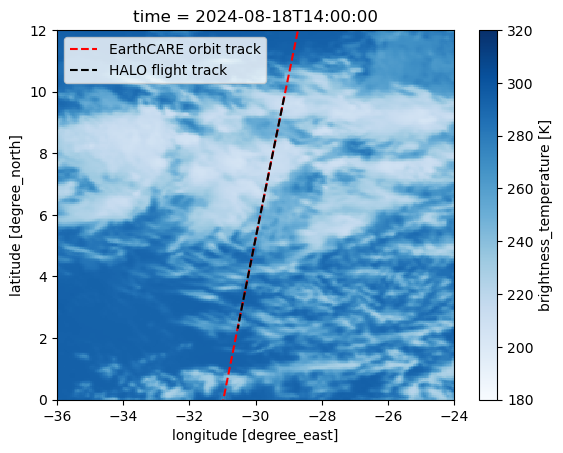

In [68]:
bt.sel(
    latitude=slice(12,0), longitude=slice(-36, -24)
).plot(cmap="Blues", vmin=180, vmax=320)

l_ec = plt.plot(fmr_ds.longitude, fmr_ds.latitude, "r--")
l_halo = plt.plot(ds_halo_regridded.lon, ds_halo_regridded.lat, "k--")

plt.legend(
    [l_ec[0], l_halo[0]],
    ["EarthCARE orbit track", "HALO flight track"]
)